In [1]:
%pip install pandas torch transformers deepparse huggingface_hub matplotlib ipympl rdflib sentence_transformers
%matplotlib inline

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
if torch.cuda.is_available():
    print("CUDA - available devices:")
    for i in range(torch.cuda.device_count()):
        print(f"  {i}: {torch.cuda.get_device_name(i)}")
    device = torch.device('cuda')
elif torch.accelerator.is_available(): # Support other hardware accelators
    device = torch.accelerator.current_accelerator()
else:
    print("WARNING: Running on CPU")
    device = torch.device('cpu')
print(f"Torch version: {torch.__version__}, Device: {device}")

CUDA - available devices:
  0: NVIDIA A100 80GB PCIe
  1: NVIDIA A100 80GB PCIe
Torch version: 2.10.0+cu128, Device: cuda


In [3]:
from huggingface_hub import notebook_login
notebook_login()

In [4]:
from collections import OrderedDict
import pandas as pd
import json

ENTITIES_TO_PREDICT = [
    "HouseNumber",
    "StreetName",
    "City",
    "State",
    "Country"
]

csv_read_args = dict(keep_default_na=False, dtype=str, na_values=[""])

bzkopen_train = pd.read_csv("open_data/bzkopen_addresses_train.csv", **csv_read_args)
bzkopen_val = pd.read_csv("open_data/bzkopen_addresses_val.csv", **csv_read_args)
bzkopen_test = pd.read_csv("open_data/bzkopen_addresses_test.csv", **csv_read_args)

ALL_ENTITY_TYPES = [
    "UnitNumber",
    "HouseNumber",
    "StreetName",
    "Neighborhood",
    "City",
    "District",
    "Region",
    "State",
    "Country",
    "PostalCode"
]

FIXED_EXAMPLES = [
    ("Berlin, Alexanderplatz 1, 10178", 
     OrderedDict([("City" , "Berlin"), ("StreetName", "Alexanderplatz"), ("HouseNumber", "1")])),
    ("Braunschweig, Uferstr. 25", # From BZK open training set
     OrderedDict([("City", "Braunschweig"), ("StreetName", "Uferstr."), ("HouseNumber", "25")])),
    ("808 Westend Avenue, New York 25, N.Y.", # From BZK open training set
        OrderedDict([("StreetName", "Westend Avenue"), ("HouseNumber", "808"), 
        ("City", "New York"), ("State", "N.Y.")])),
]



In [5]:

from mllms import JsonDictPromptTemplate, JSONTuplesPromptTemplate


PROMPTS = [
    JsonDictPromptTemplate("Segment addresses into their components.\n"
    "Output only a JSON object with the following keys: " + ", ".join(ENTITIES_TO_PREDICT) + ". "
    "Do not include fields that cannot be determined and do not try to guess their values. "
    "For example, if the address is simply \"Berlin\" then the field \"Country\" should be null. "
    "Addresses will most times be written in german, meaning country and city names may be in "
    "german and the addresses "
    "may include german terms such as:\n"
    " - \"burg\" or \"stadt\" for city\n"
    " - \"straße\" or its abbreviation \"str.\" for street.\n"
    "These terms may occur as a suffix to another word.\n%(examples)s"
    "Now segment the following address:\n%(address)s"),

    JSONTuplesPromptTemplate("Annotate address components with the respective types. "
    "Consider the component types: " + ", ".join(ENTITIES_TO_PREDICT + ["Other"]) + ". "
    "Not all addresses will contain all component types and you must not guess the missing ones. "
    "Addresses will most times be written in german, meaning country and city names may be in "
    "german and the addresses "
    "may include german terms such as:\n"
    " - \"burg\" or \"stadt\" for city\n"
    " - \"straße\" or its abbreviation \"str.\" for street.\n"
    "These terms may occur as a suffix to another word.\n"
    "Output only a JSON list of [component, type] tuples.\n%(examples)s"
    "Now annotate the following address:\n%(address)s"),

    JsonDictPromptTemplate("You are a german archivist handling the digitalization of german documents from the "
    "compensation efforts that followed the second world war. Your current task consists of annotating addresses found "
    "in the archival documents, identifying the respective components of each address. "
    "Consider the component types: " + ", ".join(ENTITIES_TO_PREDICT + ["Other"]) + ". "
    "It is essential that you remain loyal to the original text and do not add any information not "
    "explictly mentioned in the address. "
    "Addresses will most times be written in german, meaning country and city names may be in "
    "german. The addresses may include german terms such as:\n"
    " - \"burg\" or \"stadt\" for city\n"
    " - \"straße\", \"avenue\" or its abbreviation \"str.\" and \"av.\" for street.\n"
    "These terms may occur as a suffix to another word.\n"
    "Format the output as a JSON object with the component types as keys.\n%(examples)s"
    "Now annotate the following address:\n%(address)s"),

    JSONTuplesPromptTemplate("You are a german archivist handling the digitalization of german documents from the "
    "compensation efforts that followed the second world war. Your current task consists of annotating addresses found "
    "in the archival documents, identifying the respective components of each address. "
    "Consider the component types: " + ", ".join(ENTITIES_TO_PREDICT + ["Other"]) + ". "
    "It is essential that you remain loyal to the original text and do not add any information not "
    "explictly mentioned in the address. "
    "Addresses will most times be written in german, meaning country and city names may be in "
    "german. The addresses may include german terms such as:\n"
    " - \"burg\" or \"stadt\" for city\n"
    " - \"straße\", \"avenue\" or its abbreviation \"str.\" and \"av.\" for street.\n"
    "These terms may occur as a suffix to another word.\n"
    "Format the output as a JSON list of [component, type] tuples.\n%(examples)s"
    "Now annotate the following address:\n%(address)s"),
]



for i, prompt in enumerate(PROMPTS):
    print(f"Prompt {i}:")
    print(prompt.template)
    print()

Prompt 0:
Segment addresses into their components.
Output only a JSON object with the following keys: HouseNumber, StreetName, City, State, Country. Do not include fields that cannot be determined and do not try to guess their values. For example, if the address is simply "Berlin" then the field "Country" should be null. Addresses will most times be written in german, meaning country and city names may be in german and the addresses may include german terms such as:
 - "burg" or "stadt" for city
 - "straße" or its abbreviation "str." for street.
These terms may occur as a suffix to another word.
%(examples)sNow segment the following address:
%(address)s

Prompt 1:
Annotate address components with the respective types. Consider the component types: HouseNumber, StreetName, City, State, Country, Other. Not all addresses will contain all component types and you must not guess the missing ones. Addresses will most times be written in german, meaning country and city names may be in german 

In [6]:
from deepparse_parser import DeepParseParser
from libpostal_client import LibpostalClient
from token_classifiers import TokenClassifierAddressParser
from mllms import LlamaAddressParsingModel, FixedExamples, ZeroShot, SimilarExamples
from itertools import combinations
import time
from pathlib import Path
from utils import compare_preds

model_configs = [
    {
        "name" : "libpostal",
        "factory": LibpostalClient,
        "cleanup": lambda client: client.close(),
        "family": "libpostal"
    },
    {
        "name" : "libpostal-expanded",
        "factory": LibpostalClient,
        "factory_kargs" : {"expand_before_parsing": True},
        "cleanup": lambda client: client.close(),
        "family": "libpostal"
    },
    {
        "name" : "deepparse-bpemb",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "bpemb", "device": device},
        "family": "deepparse"
    },
    {
        "name" : "deepparse-fasttext",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "fasttext", "device": device},
        "family": "deepparse"
    },
    {
        "name" : "deepparse-bpemb-attention",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "bpemb", "attention_mechanism": True, "device": device},
        "family": "deepparse"
    },
    {
        "name" : "deepparse-fasttext-attention",
        "factory": DeepParseParser,
        "factory_kargs": {"model_type": "fasttext", "attention_mechanism": True, "device": device},
        "family": "deepparse"
    },
    {
        "name" : "xlm-roberta-large-address-parser", # from https://arxiv.org/abs/2404.05632
        "factory": TokenClassifierAddressParser,
        "factory_kargs": {"model_name" : "hm-haitham/xlm-roberta-large-address-parser", "device": device},
        "family": "xlm-roberta"
    },
    {
        "name" : "xlm-roberta-large-address-parser-word-avg",
        "factory": TokenClassifierAddressParser,
        "factory_kargs": {"model_name" : "hm-haitham/xlm-roberta-large-address-parser", "device": device, "aggregation_strategy": "average"},
        "family": "xlm-roberta"
    },
    {
        "name" : "xlm-roberta-large-address-parser-word-max",
        "factory": TokenClassifierAddressParser,
        "factory_kargs": {"model_name" : "hm-haitham/xlm-roberta-large-address-parser", "device": device, "aggregation_strategy": "max"},
        "family": "xlm-roberta"
    }
]

LLAMA_MODELS = [
    ("Llama-3.2-1B", "meta-llama/Llama-3.2-1B-Instruct"),
    ("Llama-3.2-3B", "meta-llama/Llama-3.2-3B-Instruct"),
    ("Llama-3-8B", "meta-llama/Meta-Llama-3-8B-Instruct"),
]

example_strategies = [
    ("0shot", ZeroShot()),
    ("fixed3shot", FixedExamples(FIXED_EXAMPLES)),
    (f"similar1shot", {
        "factory" : SimilarExamples,
        "factory_kargs": dict(
            example_addresses=bzkopen_train["FullAddress"],
            example_labels=bzkopen_train,
            num_examples=1,
            labels_to_include=ENTITIES_TO_PREDICT,
            device=device
        )
    }),
    (f"similar5shot", {
        "factory" : SimilarExamples,
        "factory_kargs": dict(
            example_addresses=bzkopen_train["FullAddress"],
            example_labels=bzkopen_train,
            num_examples=5,
            labels_to_include=ENTITIES_TO_PREDICT,
            device=device
        )
    })
]

def _make_llama_config(model_id, model_path, prompt_id, example_strategy_id, example_strategy):
        return {
            "name": f"{model_id}-prompt{prompt_id}-{example_strategy_id}",
            "factory": LlamaAddressParsingModel,
            "factory_kargs" : {
                "model_name": model_path,
                "prompt": PROMPTS[prompt_id],
                "example_strategy": example_strategy,
                "device": device
            },
            "family": "Llama"
        }

for model_id, model_name in LLAMA_MODELS:
    for example_strategy_id, example_strategy in example_strategies[:-1]:
        model_configs.append(_make_llama_config(model_id, model_name, 2, example_strategy_id, example_strategy))
    for prompt_id in range(len(PROMPTS)):
        model_configs.append(_make_llama_config(model_id, model_name, prompt_id, *example_strategies[-1]))

example_strategies = [("0shot", ZeroShot())] + [(f"similar{n}shot", {
    "factory" : SimilarExamples,
    "factory_kargs": dict(
        example_addresses=bzkopen_train["FullAddress"],
        example_labels=bzkopen_train,
        num_examples=n,
        labels_to_include=ENTITIES_TO_PREDICT,
        device=device
    )
}) for n in range(1, 6)]

n_shot_model_configs = []
for example_strategy_id, example_strategy in example_strategies:
    n_shot_model_configs.append(_make_llama_config(
         "Llama-3-8B", "meta-llama/Meta-Llama-3-8B-Instruct", 2, example_strategy_id, example_strategy))

for config in model_configs:
    print(f"Model config: {repr(config)}")


Model config: {'name': 'libpostal', 'factory': <class 'libpostal_client.LibpostalClient'>, 'cleanup': <function <lambda> at 0x7f0ccfee27a0>, 'family': 'libpostal'}
Model config: {'name': 'libpostal-expanded', 'factory': <class 'libpostal_client.LibpostalClient'>, 'factory_kargs': {'expand_before_parsing': True}, 'cleanup': <function <lambda> at 0x7f0da5018400>, 'family': 'libpostal'}
Model config: {'name': 'deepparse-bpemb', 'factory': <class 'deepparse_parser.DeepParseParser'>, 'factory_kargs': {'model_type': 'bpemb', 'device': device(type='cuda')}, 'family': 'deepparse'}
Model config: {'name': 'deepparse-fasttext', 'factory': <class 'deepparse_parser.DeepParseParser'>, 'factory_kargs': {'model_type': 'fasttext', 'device': device(type='cuda')}, 'family': 'deepparse'}
Model config: {'name': 'deepparse-bpemb-attention', 'factory': <class 'deepparse_parser.DeepParseParser'>, 'factory_kargs': {'model_type': 'bpemb', 'attention_mechanism': True, 'device': device(type='cuda')}, 'family': 'd

In [ ]:
import traceback

def eval(dataset, configs, cols_to_predict, pred_cache_path=None):
    if pred_cache_path is not None:
        pred_cache_path = Path(pred_cache_path)
    if pred_cache_path is None or not pred_cache_path.exists():
        cached_preds = {}
    else:
        print(f"Loading cached predictions...")
        with open(pred_cache_path, "r") as f:
            cached_preds = json.load(f)
    
    preds_per_config = []
    model_results = []

    for config in configs:
        config_name = config["name"]
        if config_name in cached_preds:
            print(f"Using cached predictions for model {config_name}... To avoid this delete or rename the file {pred_cache_path} or delete the entry for {config_name} inside it.")
            preds = cached_preds[config_name]["preds"]
            deltatime = cached_preds[config_name]["deltatime"]
        else:
            try:
                print(f"Loading model {config_name}...")
                pargs = config.get("factory_pargs", [])
                kargs = config.get("factory_kargs", {})
                model = config["factory"](*pargs, **kargs)
                print(f"Segmenting addresses...")
                start = time.monotonic()
                preds = model.parse_addresses(dataset["FullAddress"].tolist())
                deltatime = time.monotonic() - start
                if "cleanup" in config:
                    print("Cleaning up model resources...")
                    config["cleanup"](model)
                print("Parsing model responses...")
                if pred_cache_path is not None:
                    cached_preds[config_name] = {
                        "preds": preds,
                        "deltatime": deltatime
                    }
            except Exception as e:
                print(f"Error while processing model {config_name}: {e}")
                traceback.print_exc()
                model_results.append({
                    "error" : len(dataset),
                    "errorRate" : 1.0
                })
                continue
        preds_df = pd.DataFrame(preds)
        preds_per_config.append(preds_df)
        print("Computing metrics...")
        metrics = compare_preds(preds_df, dataset[cols_to_predict], target_columns=cols_to_predict)
        metrics["deltatime"] = deltatime
        metrics["rate"] = len(dataset) / metrics["deltatime"]
        metrics["error"] = preds_df["error"].notna().sum() if "error" in preds_df.columns else 0
        metrics["errorRate"] = metrics["error"] / len(dataset)
        preds_df["config_name"] = config_name
        preds_df["FullAddress"] = dataset["FullAddress"]

        model_results.append(metrics)
        print(f"Results for model {config_name}: {metrics}")

    if pred_cache_path is not None:
        with open(pred_cache_path, "w") as f:
            json.dump(cached_preds, f)

    preds_per_config_df = pd.concat(preds_per_config)
    default_cols = ["config_name", "FullAddress"] + cols_to_predict
    new_order = default_cols + [col for col in preds_per_config_df.columns if col not in default_cols]
    preds_per_config_df = preds_per_config_df[new_order]

    results_df = pd.DataFrame(model_results, index = [config["name"] for config in configs])
    return preds_per_config_df, results_df

def best_config_per_family(df):
    df = df.groupby(by={config["name"]:config.get("family", config["name"]) for config in model_configs}, sort=False).apply(
        lambda group: group.loc[[config for config in group.index if any(group[col].max() == group.at[config, col] for col in group.columns)]]
    )
    df = df.droplevel(0)
    return df

def bold_max(col):
    return ['font-weight: bold' if v == col.max() else '' for v in col]

preds_per_config, model_statistics = eval(bzkopen_val, model_configs, ENTITIES_TO_PREDICT, pred_cache_path="cached_preds_val.json")
model_statistics[["accuracy", "precision", "recall", "f1", "average_similarity", "errorRate", "rate"]].style.apply(bold_max)

Loading cached predictions...
Using cached predictions for model libpostal... To avoid this delete or rename the file cached_preds_val.json or delete the entry for libpostal inside it.
Computing metrics...
Results for model libpostal: OrderedDict({'accuracy': 0.7394736842105263, 'precision': 0.6, 'recall': 0.4243421052631579, 'f1': 0.4971098265895954, 'accuracy_with_tol_1': 0.7473684210526316, 'accuracy_with_tol_2': 0.7539473684210526, 'accuracy_with_tol_3': 0.7644736842105263, 'accuracy_with_tol_4': 0.7881578947368421, 'average_levenshtein': 2.031578947368421, 'average_similarity': 0.7702413626939374, 'average_levenshtein_match': 2.4863123993558776, 'average_similarity_match': 0.9426464342148025, 'no_match_rate': 0.18289473684210522, 'deltatime': 0.011711865663528442, 'rate': 12978.29093731313, 'error': 0, 'errorRate': 0.0})
Using cached predictions for model libpostal-expanded... To avoid this delete or rename the file cached_preds_val.json or delete the entry for libpostal-expanded 

,accuracy,precision,recall,f1,average_similarity,errorRate,rate
libpostal,0.739474,0.600000,0.424342,0.497110,0.770241,0.000000,12978.290937
libpostal-expanded,0.740789,0.538136,0.417763,0.470370,0.797097,0.000000,4654.685295
deepparse-bpemb,0.432895,0.272727,0.236842,0.253521,0.495169,0.000000,515.352933
deepparse-fasttext,0.475000,0.339416,0.305921,0.321799,0.537354,0.000000,4235.988953
deepparse-bpemb-attention,0.339474,0.103896,0.078947,0.089720,0.373814,0.000000,1280.725862
deepparse-fasttext-attention,0.311842,0.150327,0.151316,0.150820,0.347338,0.000000,2880.833467
xlm-roberta-large-address-parser,0.806579,0.606667,0.598684,0.602649,0.844694,0.000000,490.207234
xlm-roberta-large-address-parser-word-avg,0.819737,0.641638,0.618421,0.629816,0.852799,0.000000,509.886574
xlm-roberta-large-address-parser-word-max,0.815789,0.642361,0.608553,0.625000,0.847758,0.000000,549.563027
Llama-3.2-1B-prompt2-0shot,0.435526,0.267176,0.460526,0.338164,0.465559,0.065789,19.085553


In [8]:
train_preds_per_config, model_train_statistics = eval(bzkopen_train, model_configs, ENTITIES_TO_PREDICT, pred_cache_path="cached_preds_train.json")
model_train_statistics[["accuracy", "precision", "recall", "f1", "average_similarity", "errorRate", "rate"]].style.apply(bold_max)

Loading cached predictions...
Using cached predictions for model libpostal... To avoid this delete or rename the file cached_preds_train.json or delete the entry for libpostal inside it.
Computing metrics...
Results for model libpostal: OrderedDict({'accuracy': 0.74526588845655, 'precision': 0.5920155793573515, 'recall': 0.4222222222222222, 'f1': 0.4929063640048642, 'accuracy_with_tol_1': 0.7559014267185473, 'accuracy_with_tol_2': 0.7623865110246433, 'accuracy_with_tol_3': 0.7750972762645915, 'accuracy_with_tol_4': 0.791958495460441, 'average_levenshtein': 2.046692607003891, 'average_similarity': 0.7776491918214781, 'average_levenshtein_match': 2.5183530162783274, 'average_similarity_match': 0.9568584853085854, 'no_match_rate': 0.18728923476005188, 'deltatime': 0.049197323620319366, 'rate': 15671.584209543531, 'error': 0, 'errorRate': 0.0})
Using cached predictions for model libpostal-expanded... To avoid this delete or rename the file cached_preds_train.json or delete the entry for li

,accuracy,precision,recall,f1,average_similarity,errorRate,rate
libpostal,0.745266,0.592016,0.422222,0.492906,0.777649,0.000000,15671.584210
libpostal-expanded,0.742153,0.533451,0.420833,0.470497,0.789769,0.000000,9814.859160
deepparse-bpemb,0.467445,0.301016,0.267361,0.283192,0.523064,0.000000,1790.312396
deepparse-fasttext,0.498054,0.363708,0.321528,0.341320,0.549587,0.000000,4721.130670
deepparse-bpemb-attention,0.367834,0.100840,0.075000,0.086022,0.395823,0.000000,1433.883424
deepparse-fasttext-attention,0.344228,0.161356,0.165278,0.163293,0.374884,0.000000,3220.390025
xlm-roberta-large-address-parser,0.805707,0.623663,0.647917,0.635559,0.835744,0.000000,595.146506
xlm-roberta-large-address-parser-word-avg,0.814267,0.651163,0.661111,0.656099,0.840891,0.000000,544.064929
xlm-roberta-large-address-parser-word-max,0.812451,0.649897,0.654861,0.652369,0.838960,0.000000,593.212064
Llama-3.2-1B-prompt2-0shot,0.412970,0.246026,0.472917,0.323669,0.447629,0.058366,19.059290


In [9]:
model_train_statistics[["accuracy", "f1"]].merge(
    model_statistics[["accuracy", "f1"]],
    left_index=True, right_index=True, suffixes=("_train", "_val")
).style.apply(bold_max)

,accuracy_train,f1_train,accuracy_val,f1_val
libpostal,0.745266,0.492906,0.739474,0.497110
libpostal-expanded,0.742153,0.470497,0.740789,0.470370
deepparse-bpemb,0.467445,0.283192,0.432895,0.253521
deepparse-fasttext,0.498054,0.341320,0.475000,0.321799
deepparse-bpemb-attention,0.367834,0.086022,0.339474,0.089720
deepparse-fasttext-attention,0.344228,0.163293,0.311842,0.150820
xlm-roberta-large-address-parser,0.805707,0.635559,0.806579,0.602649
xlm-roberta-large-address-parser-word-avg,0.814267,0.656099,0.819737,0.629816
xlm-roberta-large-address-parser-word-max,0.812451,0.652369,0.815789,0.625000
Llama-3.2-1B-prompt2-0shot,0.412970,0.323669,0.435526,0.338164


In [10]:
preds_per_config

,config_name,FullAddress,HouseNumber,StreetName,City,State,Country,house,state_district,unit,...,Postal Address,Type,Town,Compartment,Lagername,Kreismann,Location,Bez.Mies/Böhmen,HouseNumber ; City,StreetSuffix
0,libpostal,"Regensburg, Königstr. 2/I",2/i,königstr.,NaN,NaN,NaN,regensburg,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,libpostal,Dortmund,NaN,NaN,dortmund,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,libpostal,"Nürnberg, Nibelungenstrasse 8",8,nibelungenstrasse,NaN,NaN,NaN,nürnberg,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,libpostal,Jöhlingen/Krs.Durlach/Baden.,NaN,NaN,NaN,NaN,NaN,jöhlingen/krs.durlach/baden.,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,libpostal,"8 Burlington Road, Manchester 20/England.",8___20/england.,burlington road manchester,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147,Llama-3-8B-prompt3-similar5shot,2114-79 St. Jackson Heights. N.Y. USA,2114-79,NaN,Jackson Heights,N.Y.,USA,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,Llama-3-8B-prompt3-similar5shot,Losone CSR,NaN,NaN,Losone,NaN,CSR,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149,Llama-3-8B-prompt3-similar5shot,"1544, Union St., Brooklyn, 13 N.Y.",1544,Union St.,Brooklyn,N.Y.,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,Llama-3-8B-prompt3-similar5shot,Rum.,NaN,NaN,NaN,NaN,Rum.,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
def look_at_conversation(full_conversation):
    conversation = json.loads(full_conversation)[0]["generated_text"]
    for i, turn in enumerate(conversation):
        print(f"Turn {i} - Role: {turn['role']}")
        print(f"Content:\n{turn['content']}")
        print()

for _, row in preds_per_config[preds_per_config["config_name"] == "Llama-3-8B-prompt2-similar5shot"].sample(5).iterrows():
    look_at_conversation(row["fullConversation"])
    print("-" * 50)

Turn 0 - Role: user
Content:
You are a german archivist handling the digitalization of german documents from the compensation efforts that followed the second world war. Your current task consists of annotating addresses found in the archival documents, identifying the respective components of each address. Consider the component types: HouseNumber, StreetName, City, State, Country, Other. It is essential that you remain loyal to the original text and do not add any information not explictly mentioned in the address. Addresses will most times be written in german, meaning country and city names may be in german. The addresses may include german terms such as:
 - "burg" or "stadt" for city
 - "straße", "avenue" or its abbreviation "str." and "av." for street.
These terms may occur as a suffix to another word.
Format the output as a JSON object with the component types as keys.
Consider the following examples:
Address: Eitorf, Bahnhofstr. 35 Reg.Bez. Köln
```json{"City": "Eitorf", "Stree

In [12]:
preds_per_nshots, model_statistics_nshots = eval(bzkopen_val, n_shot_model_configs, ENTITIES_TO_PREDICT, pred_cache_path="cached_similar_nshot_preds_val.json")
train_preds_per_nshots, train_model_statistics_nshots = eval(bzkopen_train, n_shot_model_configs, ENTITIES_TO_PREDICT, pred_cache_path="cached_similar_nshot_preds_train.json")

Loading cached predictions...
Using cached predictions for model Llama-3-8B-prompt2-0shot... To avoid this delete or rename the file cached_similar_nshot_preds_val.json or delete the entry for Llama-3-8B-prompt2-0shot inside it.
Computing metrics...
Results for model Llama-3-8B-prompt2-0shot: OrderedDict({'accuracy': 0.7328947368421053, 'precision': 0.6309523809523809, 'recall': 0.5230263157894737, 'f1': 0.5719424460431655, 'accuracy_with_tol_1': 0.7421052631578947, 'accuracy_with_tol_2': 0.7644736842105263, 'accuracy_with_tol_3': 0.7855263157894737, 'accuracy_with_tol_4': 0.8118421052631579, 'average_levenshtein': 1.9828947368421053, 'average_similarity': 0.7478473515444959, 'average_levenshtein_match': 2.562925170068027, 'average_similarity_match': 0.9666054203636342, 'no_match_rate': 0.22631578947368425, 'deltatime': 53.154837407171726, 'rate': 2.8595704062767378, 'error': 32, 'errorRate': 0.21052631578947367})
Using cached predictions for model Llama-3-8B-prompt2-similar1shot... To

In [13]:
default_cols = ["config_name", "FullAddress"] + ENTITIES_TO_PREDICT
preds_vs_trues = preds_per_config[default_cols].merge(
    bzkopen_val[default_cols[1:]], on="FullAddress", suffixes=("_pred", "_true"), how="left")
preds_vs_trues = preds_vs_trues[["config_name", "FullAddress"] + [new_col for col in ENTITIES_TO_PREDICT for new_col in [f"{col}_pred", f"{col}_true"]]] # Order the columns for readability
preds_vs_trues

,config_name,FullAddress,HouseNumber_pred,HouseNumber_true,StreetName_pred,StreetName_true,City_pred,City_true,State_pred,State_true,Country_pred,Country_true
0,libpostal,"Regensburg, Königstr. 2/I",2/i,2/I,königstr.,Königstr.,NaN,Regensburg,NaN,NaN,NaN,NaN
1,libpostal,Dortmund,NaN,NaN,NaN,NaN,dortmund,Dortmund,NaN,NaN,NaN,NaN
2,libpostal,"Nürnberg, Nibelungenstrasse 8",8,8,nibelungenstrasse,Nibelungenstrasse,NaN,Nürnberg,NaN,NaN,NaN,NaN
3,libpostal,Jöhlingen/Krs.Durlach/Baden.,NaN,NaN,NaN,NaN,NaN,Jöhlingen,NaN,Baden,NaN,NaN
4,libpostal,"8 Burlington Road, Manchester 20/England.",8___20/england.,8,burlington road manchester,Burlington Road,NaN,Manchester,NaN,NaN,NaN,England
...,...,...,...,...,...,...,...,...,...,...,...,...
4915,Llama-3-8B-prompt3-similar5shot,2114-79 St. Jackson Heights. N.Y. USA,2114-79,2114,NaN,79 St.,Jackson Heights,N.Y.,N.Y.,NaN,USA,USA
4916,Llama-3-8B-prompt3-similar5shot,Losone CSR,NaN,NaN,NaN,NaN,Losone,Losone,NaN,NaN,CSR,CSR
4917,Llama-3-8B-prompt3-similar5shot,"1544, Union St., Brooklyn, 13 N.Y.",1544,1544,Union St.,Union St.,Brooklyn,N.Y.,N.Y.,NaN,NaN,NaN
4918,Llama-3-8B-prompt3-similar5shot,Rum.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Rum.,Rum.


In [ ]:

metric = "f1"
best_config_per_family(model_statistics[[metric]])


,f1
libpostal,0.497110
deepparse-fasttext,0.321799
xlm-roberta-large-address-parser-word-avg,0.629816
Llama-3-8B-prompt2-similar5shot,0.822047


In [15]:
def get_n_shots(config):
    config_name = config["name"]
    config_prefix = "-".join([part for part in config_name.split("-") if not part.endswith("shot")])
    example_strategy = config.get("factory_kargs", {}).get("example_strategy")
    if isinstance(example_strategy, ZeroShot):
        return 0, config_prefix
    elif isinstance(example_strategy, FixedExamples):
        return len(example_strategy.examples), config_prefix
    elif isinstance(example_strategy, dict):
        if example_strategy.get("factory") == SimilarExamples:
            num_examples = example_strategy.get("factory_kargs", {}).get("num_examples")
            if num_examples is not None:
                return num_examples, config_prefix
    return None, None

metric_per_shot = pd.DataFrame(columns=pd.MultiIndex.from_tuples(
    [(split, get_n_shots(config)[1], config["name"]) 
     for config in n_shot_model_configs for split in ["train", "val"]],
    names=["split", "config_prefix", "config_name"]
))


for config in n_shot_model_configs:
    config_name = config["name"]
    n_shots, config_prefix = get_n_shots(config)
    assert n_shots is not None
    for split, stats in [("train", train_model_statistics_nshots), ("val", model_statistics_nshots)]:
            metric_per_shot.at[n_shots, (split, config_prefix, config_name)] = stats.at[config_name, metric]
metric_per_shot = metric_per_shot.stack(level="config_name").groupby(level=0).mean()      
metric_per_shot.index.name = None
if len(set(metric_per_shot.columns.get_level_values("config_prefix"))) == 1:
    metric_per_shot = metric_per_shot.droplevel("config_prefix", axis=1)
else:
    for split in metric_per_shot.columns.get_level_values("split").unique():
        metric_per_shot[split, "mean"] = metric_per_shot[split].mean(axis=1)
    metric_per_shot.columns = ['_'.join(col).strip('_') for col in metric_per_shot.columns]


In [16]:
metric_per_shot.index

Index([0, 1, 2, 3, 4, 5], dtype='int64')

<Axes: title={'center': 'f1 per number of (fixed) examples'}, xlabel='Number of examples', ylabel='f1'>

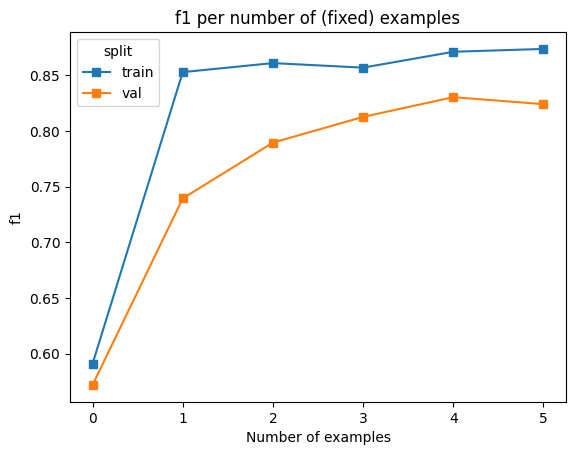

In [17]:
metric_per_shot.plot(
    kind="line", marker="s", xticks=metric_per_shot.index,
    xlabel="Number of examples", ylabel=metric, 
    title=f"{metric} per number of (fixed) examples"
)

In [18]:
metric_per_column = pd.DataFrame(index=model_statistics.index, columns=ENTITIES_TO_PREDICT)
for col in ENTITIES_TO_PREDICT:
    for config in model_statistics.index:
        preds = preds_per_config[preds_per_config["config_name"] == config]
        if len(preds) == 0:
            print(f"No predictions found for config {config} and column {col}, skipping.")
            continue
        if col in preds.columns:
            value = compare_preds(preds, bzkopen_val, target_columns=[col])[metric]
            metric_per_column.at[config, col] = value
        else:
            metric_per_column.at[config, col] = pd.NA
print(f"Per-column {metric} scores:")
metric_per_column = best_config_per_family(metric_per_column)
metric_per_column.style.apply(bold_max)

Per-column f1 scores:


,HouseNumber,StreetName,City,State,Country
libpostal,0.678571,0.529915,0.400000,0.400000,0.466667
libpostal-expanded,0.678571,0.245614,0.454148,0.250000,0.608696
deepparse-bpemb,0.640000,0.027397,0.257813,0.000000,0.169492
deepparse-fasttext,0.568807,0.075758,0.363636,0.000000,0.272727
deepparse-bpemb-attention,0.231884,0.048387,0.009901,0.000000,0.180451
deepparse-fasttext-attention,0.423529,0.045455,0.090498,0.000000,0.231405
xlm-roberta-large-address-parser,0.803419,0.677686,0.462687,0.117647,0.765432
xlm-roberta-large-address-parser-word-avg,0.803419,0.722689,0.505660,0.117647,0.759494
xlm-roberta-large-address-parser-word-max,0.803419,0.728814,0.498084,0.117647,0.734177
Llama-3.2-3B-prompt1-similar5shot,0.656716,0.777778,0.720307,0.400000,0.829268


<Axes: title={'center': 'f1 per number of (fixed) examples'}, xlabel='Number of examples', ylabel='f1'>

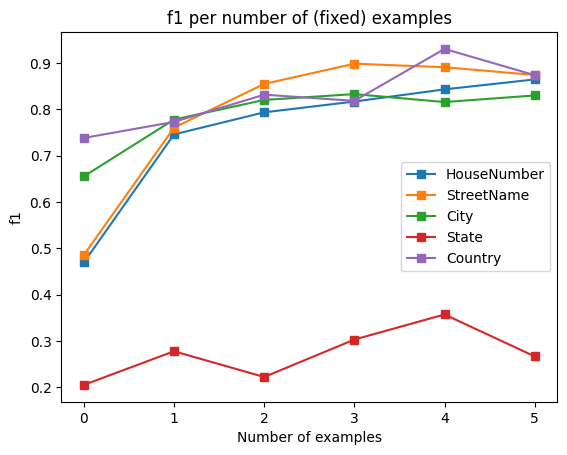

In [19]:
metric_per_column_per_shot = pd.DataFrame(
    index=pd.MultiIndex.from_product([model_statistics_nshots.index, metric_per_shot.index]),
    columns=ENTITIES_TO_PREDICT
)
for col in ENTITIES_TO_PREDICT:
    for config in n_shot_model_configs:
        config_name = config["name"]
        preds = preds_per_nshots[preds_per_nshots["config_name"] == config_name]
        if len(preds) == 0:
            print(f"No predictions found for config {config_name} and column {col}, skipping.")
            continue
        if col in preds.columns:
            value = compare_preds(preds, bzkopen_val, target_columns=[col])[metric]
            n_shots, model_name = get_n_shots(config)
            if n_shots is not None:
                metric_per_column_per_shot.at[(config_name, n_shots), col] = value
        else:
            metric_per_column_per_shot.at[(config_name, 0), col] = pd.NA

metric_per_column_per_shot = metric_per_column_per_shot.groupby(level=1).mean()
metric_per_column_per_shot.plot(
    kind="line", marker="s", xticks=metric_per_shot.index,
    xlabel="Number of examples", ylabel=metric, 
    title=f"{metric} per number of (fixed) examples"
)

In [20]:
bzk_fields = bzkopen_val["field"].unique()
print(f"bzk_fields: {bzk_fields}")
metric_per_bzk_field = pd.DataFrame(index=model_statistics.index, columns=bzk_fields)

for field in bzk_fields:
    mask = bzkopen_val["field"] == field
    subset = bzkopen_val[mask]
    for config in model_statistics.index:
        preds = preds_per_config[preds_per_config["config_name"] == config]
        if len(preds) == 0:
            print(f"No predictions found for config {config} and column {col}, skipping.")
            continue
        value = compare_preds(preds[mask], subset, target_columns=ENTITIES_TO_PREDICT)[metric]
        metric_per_bzk_field.at[config, field] = value
print(f"Per-BZK-field {metric} scores:")
metric_per_bzk_field = best_config_per_family(metric_per_bzk_field)
metric_per_bzk_field.style.apply(bold_max)

bzk_fields: <StringArray>
['ApplicantCurrentAddress',        'VictimBirthPlace',
    'VictimCurrentAddress',     'ApplicantBirthPlace',
        'VictimDeathPlace']
Length: 5, dtype: str
Per-BZK-field f1 scores:


,ApplicantCurrentAddress,VictimBirthPlace,VictimCurrentAddress,ApplicantBirthPlace,VictimDeathPlace
libpostal,0.500000,0.486486,0.450980,0.530973,0.545455
libpostal-expanded,0.411985,0.536585,0.392157,0.616667,0.800000
deepparse-fasttext,0.241993,0.595745,0.294118,0.397059,0.500000
xlm-roberta-large-address-parser-word-avg,0.594059,0.604651,0.660550,0.671756,0.909091
xlm-roberta-large-address-parser-word-max,0.594059,0.571429,0.666667,0.656250,0.909091
Llama-3.2-3B-prompt3-similar5shot,0.810127,0.680000,0.638655,0.594203,1.000000
Llama-3-8B-prompt2-similar5shot,0.860759,0.880000,0.678261,0.825175,0.909091
Llama-3-8B-prompt3-similar5shot,0.838710,0.846154,0.707965,0.771429,0.909091


<Axes: title={'center': 'f1 per number of (fixed) examples'}, xlabel='Number of examples', ylabel='f1'>

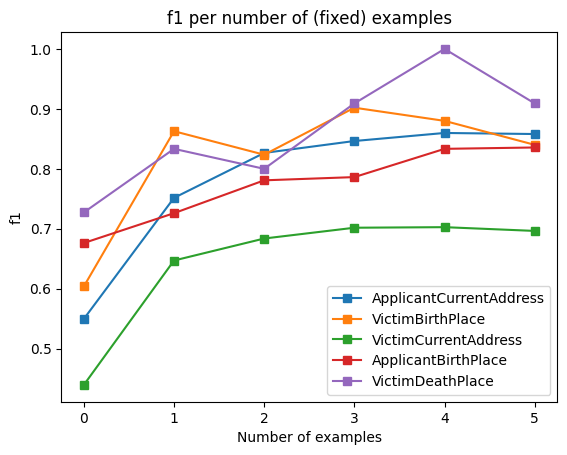

In [21]:
metric_per_bzk_field_per_shot =  pd.DataFrame(
    index=pd.MultiIndex.from_product([model_statistics_nshots.index, metric_per_shot.index]),
    columns=bzk_fields
)

for field in bzk_fields:
    mask = bzkopen_val["field"] == field
    subset = bzkopen_val[mask]
    for config in n_shot_model_configs:
        config_name = config["name"]
        preds = preds_per_nshots[preds_per_nshots["config_name"] == config_name]
        if len(preds) == 0:
            print(f"No predictions found for config {config_name} and column {col}, skipping.")
            continue
        value = compare_preds(preds[mask], subset, target_columns=ENTITIES_TO_PREDICT)[metric]
        n_shots, model_name = get_n_shots(config)
        if n_shots is not None:
            metric_per_bzk_field_per_shot.at[(config_name, n_shots), field] = value

metric_per_bzk_field_per_shot = metric_per_bzk_field_per_shot.groupby(level=1).mean()
metric_per_bzk_field_per_shot.plot(
    kind="line", marker="s", xticks=metric_per_shot.index,
    xlabel="Number of examples", ylabel=metric, 
    title=f"{metric} per number of (fixed) examples"
)